### Dataset Description

I used a preprocessed version of the California Housing dataset (housing.csv). 
The dataset already contained only numerical features, and the categorical feature 
'ocean_proximity' was not present, so no additional encoding was required.

This dataset was used to build and evaluate multiple regression models for house price prediction.

In [50]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [51]:
# Step 2: Load + Clean Dataset

import pandas as pd

df = pd.read_csv("housing.csv")

# Drop categorical column
df = df.drop("ocean_proximity", axis=1)

# Convert to numeric (safety step)
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values
df = df.fillna(df.mean())

# Check if any NaN remains
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [52]:
# 🔥 CLEAN PIPELINE (guaranteed fix)

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("housing.csv")

# Drop categorical column
df = df.drop("ocean_proximity", axis=1)

# Convert everything to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values
df = df.fillna(df.mean())

# 🔍 Check NaN BEFORE scaling
print("NaN before scaling:\n", df.isnull().sum())

# Separate features & target
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔍 Check NaN AFTER scaling
print("NaN after scaling:", np.isnan(X_scaled).sum())
print("Infinity after scaling:", np.isinf(X_scaled).sum())



# 🔍 Final check
print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test:", np.isnan(X_test).sum())

NaN before scaling:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64
NaN after scaling: 0
Infinity after scaling: 0
NaN in X_train: 0
NaN in X_test: 0


In [53]:
# Handle missing values
print(df.isnull().sum())   # check missing values

# Fill missing values with mean
df = df.fillna(df.mean())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [54]:
print(df.columns)
print(df.shape)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')
(20640, 9)


In [55]:
# Step 3: Separate Features and Target

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [57]:
# Step 5: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [58]:
import numpy as np

print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test:", np.isnan(X_test).sum())

NaN in X_train: 0
NaN in X_test: 0


In [59]:
# Step 6: Train Multiple Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}


In [60]:
# Step 7: Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, predictions, squared=False)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T
print(results_df)


                           RMSE  R2 Score
Linear Regression  71084.131168  0.614399
Ridge Regression   71080.772190  0.614435
Decision Tree      75022.004306  0.570493


In [61]:
# Step 9: Select Best Model (based on RMSE)

best_model_name = results_df["RMSE"].idxmin()
print("Best Model:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

Best Model: Ridge Regression


Ridge()

In [62]:
# Step 10: Make Predictions

y_pred = best_model.predict(X_test)

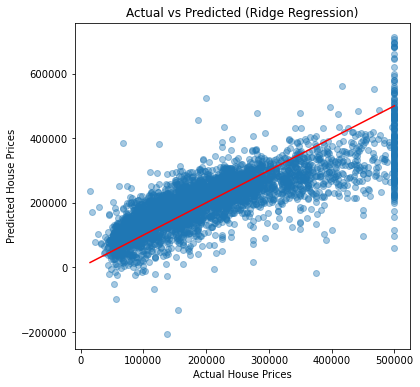

In [63]:
# Step 8: Visualization (Best Model)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted ({best_model_name})")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [64]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("Final Model Performance:")
print("RMSE:", rmse)
print("R2 Score:", r2)

Final Model Performance:
RMSE: 71080.7721900373
R2 Score: 0.6144351680255997


In [65]:
import joblib

joblib.dump(best_model, "best_model.pkl")

print("Model saved successfully!")

Model saved successfully!


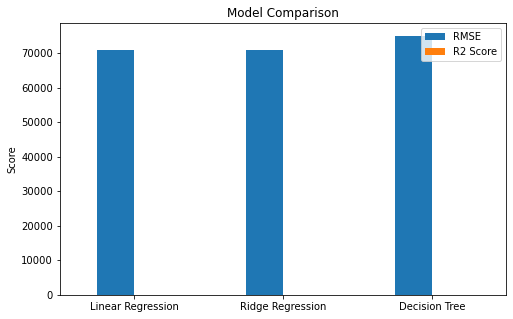

In [66]:
results_df.plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [67]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')
